# 4.6 Comparing and Validating Cluster Results

**Part:** 4 — Spatial Cluster Analysis (Chapter 4.6 of 8)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** Putting every areal method from this Part on one panel, quantifying agreement, and reporting standards

**Library:** `spatialstats.cluster` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [One Basemap, Four Methods](#3.-One-Basemap,-Four-Methods)
4.. [Quantifying Agreement](#4.-Quantifying-Agreement)
5.. [Why DBSCAN Does Not Belong on This Panel](#5.-Why-DBSCAN-Does-Not-Belong-on-This-Panel)
6.. [Comparing Two Regionalisations](#6.-Comparing-Two-Regionalisations)
7.. [Reporting Standards](#7.-Reporting-Standards)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Chapters 4.2, 4.4, and 4.5 each answered a different question about the same 217 counties. This chapter puts
their answers side by side — not to declare a winner, but to see directly how much they actually agree, and to
turn "what does this method say" into "what do *several independent* methods say", which is a meaningfully
stronger form of evidence.

| Step | What we do |
|------|------------|
| One panel | Gi*, LISA, the scan statistic, and SKATER regions, mapped together on the same 217 counties |
| Agreement | `agreement_matrix` (Jaccard) across the three significance-based methods |
| A genuine mismatch | Why the scan statistic's footprint barely overlaps Gi*/LISA at all — and why that is not a contradiction |
| Regionalisation agreement | `partition_agreement` between two different regionalisations (Chapter 4.5) |
| Reporting | What a complete cluster-analysis report states, echoing Part 2 and Part 3's own reporting standards |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.cluster import (
    getis_ord_gi, local_moran_clusters, spatial_scan, skater, agglomerative,
    agreement_matrix, partition_agreement,
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(counties)
coords = np.c_[counties.geometry.centroid.x, counties.geometry.centroid.y]
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. One Basemap, Four Methods

Re-fit every areal method from this Part on the same variable(s), and map them together.

In [2]:
gi_star = getis_ord_gi(counties["Dia_pct"], w, star=True, inference="analytic", correction="fdr")
lisa = local_moran_clusters(counties["Dia_pct"], w, permutations=999, seed=1, correction="none")
scan = spatial_scan(coords, counties["Dia_count"], population=counties["POP_Total"],
                    permutations=999, seed=1, n_clusters=3)
regions = skater(counties[["Dia_pct", "Obesity", "SVI"]], w, n_clusters=6)
print("re-fit: Gi*, LISA, scan, SKATER regions (Chapters 4.2, 4.4, 4.5)")

re-fit: Gi*, LISA, scan, SKATER regions (Chapters 4.2, 4.4, 4.5)


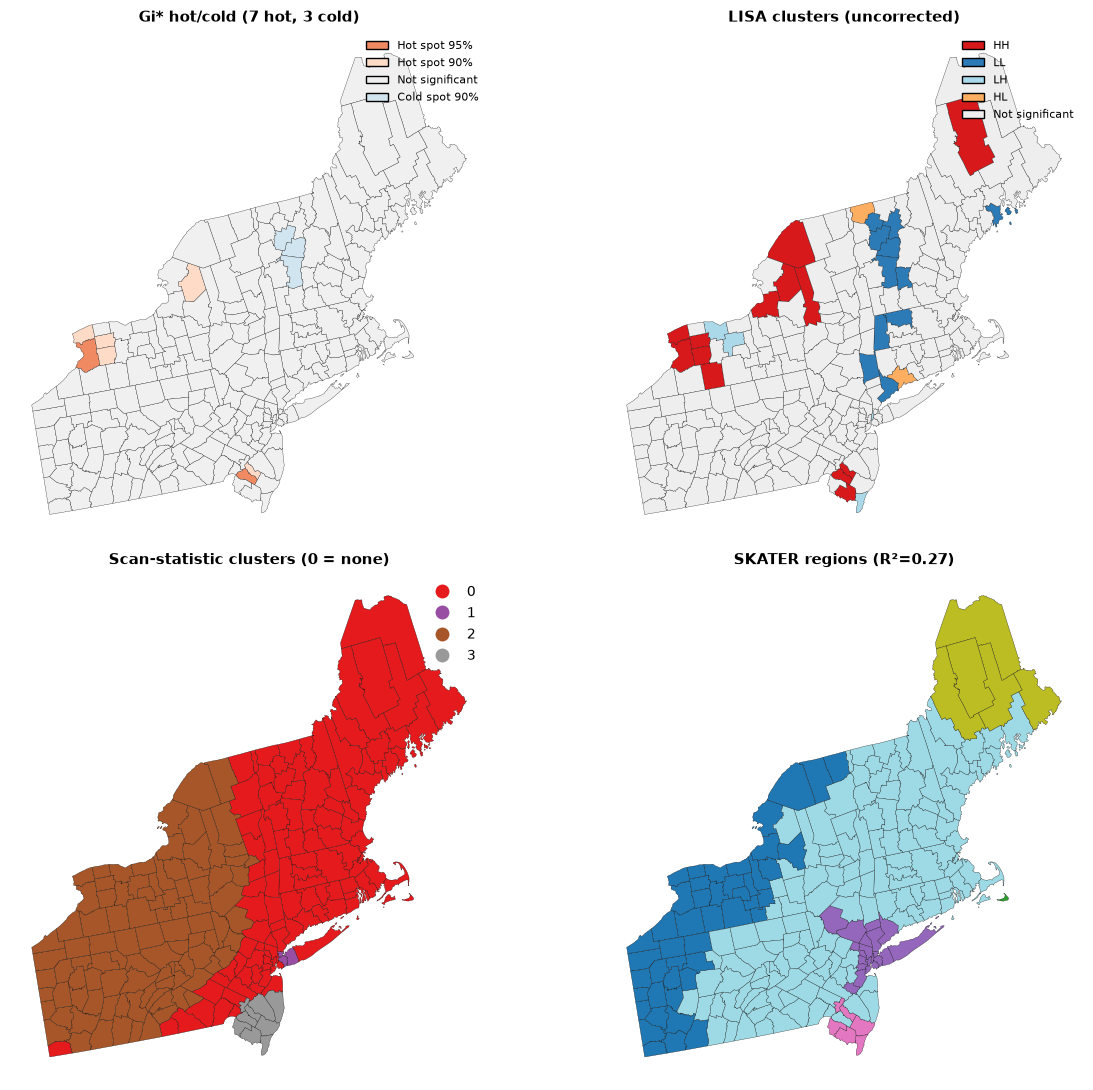

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

gi_star.plot(gdf=counties, ax=axes[0, 0])
axes[0, 0].set_title(f"Gi* hot/cold ({gi_star.hot.sum()} hot, {gi_star.cold.sum()} cold)")

lisa.plot(gdf=counties, ax=axes[0, 1])
axes[0, 1].set_title("LISA clusters (uncorrected)")

scan_frame = scan.to_frame()
counties.assign(cluster=scan_frame["cluster"]).plot(
    column="cluster", categorical=True, cmap="Set1", ax=axes[1, 0], edgecolor="k", linewidth=0.2, legend=True)
axes[1, 0].set_axis_off()
axes[1, 0].set_title("Scan-statistic clusters (0 = none)")

regions.plot(gdf=counties, ax=axes[1, 1])
axes[1, 1].set_title(f"SKATER regions (R²={regions.r2:.2f})")

plt.tight_layout()
plt.show()

Four visibly different maps from four methods applied to overlapping but not identical questions about the
same underlying data. The scan statistic's footprint (bottom left) is dramatically larger than either Gi*'s or
LISA's — Section 4 quantifies exactly how much these methods actually agree, rather than relying on the eye
alone.

***
## 4. Quantifying Agreement

In [4]:
scan_flagged = np.zeros(len(counties), dtype=bool)
for members, sig in zip(scan.members, scan.clusters["significant"]):
    if sig:
        scan_flagged[members] = True

masks = {
    "Gi* hot": gi_star.hot,
    "LISA HH": lisa.labels == "HH",
    "Scan (any sig. cluster)": scan_flagged,
}
print({name: int(mask.sum()) for name, mask in masks.items()})
agreement_matrix(masks).round(3)

{'Gi* hot': 7, 'LISA HH': 13, 'Scan (any sig. cluster)': 107}


,Gi* hot,LISA HH,Scan (any sig. cluster)
Gi* hot,1.000,0.538,0.065
LISA HH,0.538,1.000,0.111
Scan (any sig. cluster),0.065,0.111,1.000


Gi* and LISA agree moderately (Jaccard 0.54, as found already in Chapter 4.2) — both are testing a similar
local-neighbourhood idea. The scan statistic barely overlaps either (0.07 and 0.11): **this is not a failure of
any method**. The scan statistic's most likely cluster alone spans 95 population-heavy counties with a modest
but real elevation in relative risk (Chapter 4.4); Gi*/LISA are built to find *tight*, *locally extreme*
concentrations, which is a narrower and different target. A county can legitimately be "part of a broad region
with modestly excess population-weighted case burden" (flagged by the scan) without being "a locally extreme
hot spot relative to its immediate neighbours" (what Gi*/LISA look for) — the three methods are not competing
estimates of the same fact, they are answers to different, only partially overlapping questions, exactly as
Chapter 4.1 set out to establish.

In [5]:
overlap_count = np.vstack(list(masks.values())).sum(axis=0)
print(f"counties flagged by all 3 methods   : {int((overlap_count == 3).sum())}")
print(f"counties flagged by exactly 1 method : {int((overlap_count == 1).sum())}")
print(f"counties flagged by none             : {int((overlap_count == 0).sum())}")

counties flagged by all 3 methods   : 7
counties flagged by exactly 1 method : 96
counties flagged by none             : 109


The 7 counties flagged by **all three** methods are the strongest possible candidates for a genuine, robust
finding — corroborated by three structurally different statistical tests. The much larger set flagged by
exactly one method is not necessarily wrong, but each such county needs the specific method's own caveats
(Chapter 4.2's weights sensitivity, Chapter 4.4's population-adjustment logic) considered before being reported
as a standalone finding.

***
## 5. Why DBSCAN Does Not Belong on This Panel

Chapter 4.3's DBSCAN/HDBSCAN results are conspicuously absent above — deliberately, not by oversight. DBSCAN
operates on **individual point events** (14,001 Buffalo crime incidents) in a completely different city, with a
completely different variable, at a completely different spatial scale, from the **217-county areal** analysis
used throughout this chapter. There is no meaningful way to overlay a point-clustering result about crime
incidents onto a county-level choropleth about diabetes prevalence — attempting it would create a
visually-impressive but substantively meaningless composite. The general principle survives even though the
specific overlay does not: **density-based point clustering and areal hot-spot/scan methods are not
interchangeable and not directly comparable**, precisely because they operate on different kinds of spatial
data (Chapter 4.1, Section 3). A legitimate comparison would need DBSCAN run on point-level health events (say,
individual case locations) against an areal hot-spot method on the *same* underlying population — a
data configuration not available in this Part's datasets.

***
## 6. Comparing Two Regionalisations

`partition_agreement` (adjusted Rand index, normalised mutual information) is the right tool when both objects
being compared are full partitions of the same $n$ areas — exactly Chapter 4.5's SKATER-vs-agglomerative
comparison, reproduced here for completeness alongside the other agreement measures in this chapter.

In [6]:
regions_agg = agglomerative(counties[["Dia_pct", "Obesity", "SVI"]], w, n_clusters=6)
agreement = partition_agreement(regions.labels, regions_agg.labels)
print(f"SKATER vs. constrained agglomerative: adjusted Rand = {agreement['adjusted_rand']:.3f}, "
      f"NMI = {agreement['nmi']:.3f}")
print(f"(SKATER is guaranteed contiguous; agglomerative is not — Chapter 4.5, Section 4.1)")

SKATER vs. constrained agglomerative: adjusted Rand = 0.672, NMI = 0.670
(SKATER is guaranteed contiguous; agglomerative is not — Chapter 4.5, Section 4.1)


Moderate agreement (adjusted Rand 0.67) between two structurally different regionalisation algorithms is a
reasonable sign that both are picking up genuine structure in the attribute data, even though they disagree in
detail — the same logic as Section 4's cross-method agreement for point-in-space cluster detection, applied to
whole-map partitions instead.

***
## 7. Reporting Standards

Consistent with Part 2, Chapter 2.6 and Part 3, Chapter 3.5's own reporting standards, a complete cluster
analysis report states, at minimum:

1. **Which of the four questions (Chapter 4.1)** is being asked, and why that specific method answers it.
2. **The weights definition** (for Gi*/LISA/regions) and whether the finding is robust to a reasonable
   alternative (Chapter 4.2, Section 7).
3. **The significance level, multiple-testing correction, and permutation count** — and whether the FDR
   resolution limit (Chapter 4.2, Section 4.2) is a live concern at the chosen settings.
4. **Cross-method agreement**, where more than one applicable method exists — Section 4's agreement matrix, not
   just a single method's raw output.
5. **What was NOT compared and why** — Section 5's DBSCAN example shows that stating a deliberate scope
   limitation is itself part of a complete, honest report.

***
## 8. Summary and Conclusions

This chapter closed the loop across every areal method introduced in Chapters 4.2, 4.4, and 4.5.

### What we did

1. Mapped Gi*, LISA, the scan statistic, and SKATER regions together on the same 217 counties.
2. Quantified agreement: Gi*/LISA overlap moderately (Jaccard 0.54); the scan statistic barely overlaps either
   (0.07, 0.11) — explained as a genuine difference in what each method targets, not a failure of any of them.
3. Identified the 7 counties flagged by all three significance-based methods as the strongest candidates for a
   robust, corroborated finding.
4. Explained explicitly why Chapter 4.3's DBSCAN results were *not* included in the shared panel — different
   data type, different city, different variable, and forcing an overlay would manufacture false comparability.
5. Applied `partition_agreement` to two regionalisations from Chapter 4.5 (adjusted Rand 0.67).
6. Laid out five concrete reporting standards for a complete cluster-analysis report.

### Practical takeaways

- Cross-method agreement is a stronger form of evidence than any single method's output; make it a standard
  part of any cluster-detection report where more than one applicable method exists.
- Low agreement between two methods is not automatically a contradiction — check first whether they are
  actually answering the same question (Section 4's scan-vs-Gi* case) before treating disagreement as a
  problem to resolve.
- Knowing which comparisons are *not* meaningful (Section 5) is as important as making the ones that are.

### Next steps

**Chapter 4.7 (Bridges)** looks forward: space-time clustering (Part 9) and population-adjusted small-area risk
(Part 5) as the two most direct extensions of everything built in this Part.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*, 27, 93–115. | Cross-method comparison as a validation strategy |
| Rand, W. M. (1971). Objective criteria for the evaluation of clustering methods. *Journal of the American Statistical Association*, 66, 846–850. | Origin of the adjusted Rand index used in Section 6 |

### Key papers

| Paper | Contribution |
|---|---|
| Vinh, N. X., Epps, J. & Bailey, J. (2010). Information theoretic measures for clusterings comparison. *Journal of Machine Learning Research*, 11, 2837–2854. | Normalised mutual information, the second measure in `partition_agreement` |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.agreement_matrix` | Pairwise Jaccard agreement between boolean masks |
| `spatialstats.cluster.partition_agreement` | Adjusted Rand / NMI between two full partitions |
| Chapter 4.7 | Space-time and population-adjusted extensions of everything compared here |
| Chapter 4.8 | Exercises that extend this chapter's agreement analysis |